In [28]:
import numpy as np
import matplotlib.pyplot as plt
# Project Path Setup
from setup_project_path import (
    check_and_add_project_path,
)  # Script to check and add project path
check_and_add_project_path()
from src.AAA.baryrat import aaa
from src.kernel_params.kernel_params import KernelParams
from src.kernel_matrix.kernel_matrix import KernelMatrix
from src.discr_error.discr_error import DiscrError
from src.spec_dens.spec_dens import spec_dens_gapless
from scipy import integrate

In [29]:

#set up parameters for specified spectral densities 
spec_dens = lambda omega: np.sqrt(1 - omega**2)* 1/(1 + np.exp(100* (abs(omega) -1)))
beta = 0
params = KernelParams(spec_dens = spec_dens, n = 500, m = 200, N_max = 120, h = 0.01, beta = beta, phi = 0)

#create KernelMatrix object with specified parameters which we will use as reference 
K = KernelMatrix(**params.params)
D = DiscrError(**params.params)


#explicitly get the fine frequency grid
fine_grid, _, Jacobian = K._initialize_fine_grid()

# frequency points in complex plane
Z = fine_grid * np.exp(1.0j * K.phi)
Z = np.concatenate((-Z[::-1], Z)) 
# function values on the rotated contour, determined by product of spectral density and Fermi Dirac distribution and Jacobian factor
#F_positive = K.kernel[0,:] 
F = spec_dens(Z) * 1/(1 + np.exp(- params.get_param("beta") * Z)) * params.get_param("h") * Z 

print("parameters: ")
#h
print("h: ", params.get_param("h"))
#m
print("m: ", params.get_param("m"))
#n
print("n: ", params.get_param("n"))
#N_max
print("N_max: ", params.get_param("N_max"))
#delta_t
print("delta_t: ", params.get_param("delta_t"))
#beta
print("beta: ", params.get_param("beta"))



#perform AAA algorithm on spectral density multiplied with Fermi-Dirac distribution
r, errors = aaa(Z = Z, F = F, return_errors=True)
poles, residues = r.polres()


/var/folders/cg/_38xw63s1fg5wbmw91yk0qzr0000gn/T/ipykernel_93987/3183947436.py:2: RuntimeWarning: overflow encountered in exp
  spec_dens = lambda omega: np.sqrt(1 - omega**2)* 1/(1 + np.exp(100* (abs(omega) -1)))


parameters: 
h:  0.01
m:  200
n:  500
N_max:  120
delta_t:  0.1
beta:  0


/Users/julianthoenniss/Documents/PhD/code/channel_IF/RealTimeID/src/AAA/baryrat.py:280: RuntimeWarning: divide by zero encountered in divide
  C_pol = 1.0 / (pol[:,None] - zj[None,:])
/Users/julianthoenniss/Documents/PhD/code/channel_IF/RealTimeID/src/AAA/baryrat.py:280: RuntimeWarning: invalid value encountered in divide
  C_pol = 1.0 / (pol[:,None] - zj[None,:])
/Users/julianthoenniss/Documents/PhD/code/channel_IF/RealTimeID/src/AAA/baryrat.py:283: RuntimeWarning: invalid value encountered in divide
  res = N_pol / Ddiff_pol


(-0.006737946999085467-0j) (0.006737946999085467+0j)


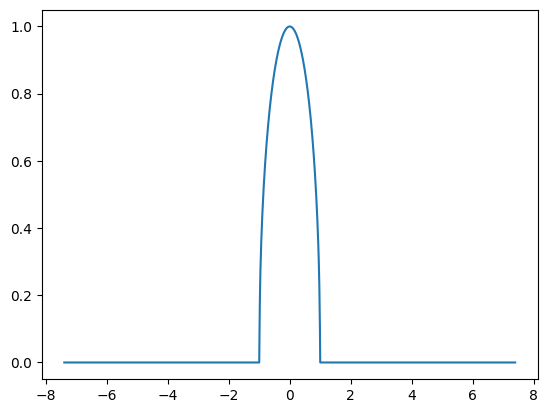

In [35]:
plt.figure()
plt.plot(Z, spec_dens(Z))


/var/folders/cg/_38xw63s1fg5wbmw91yk0qzr0000gn/T/ipykernel_93987/19286325.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  axs[0].plot(poles.real, poles.imag, 'ro', label = 'Poles', color = 'blue')


Text(0, 0.5, 'Im')

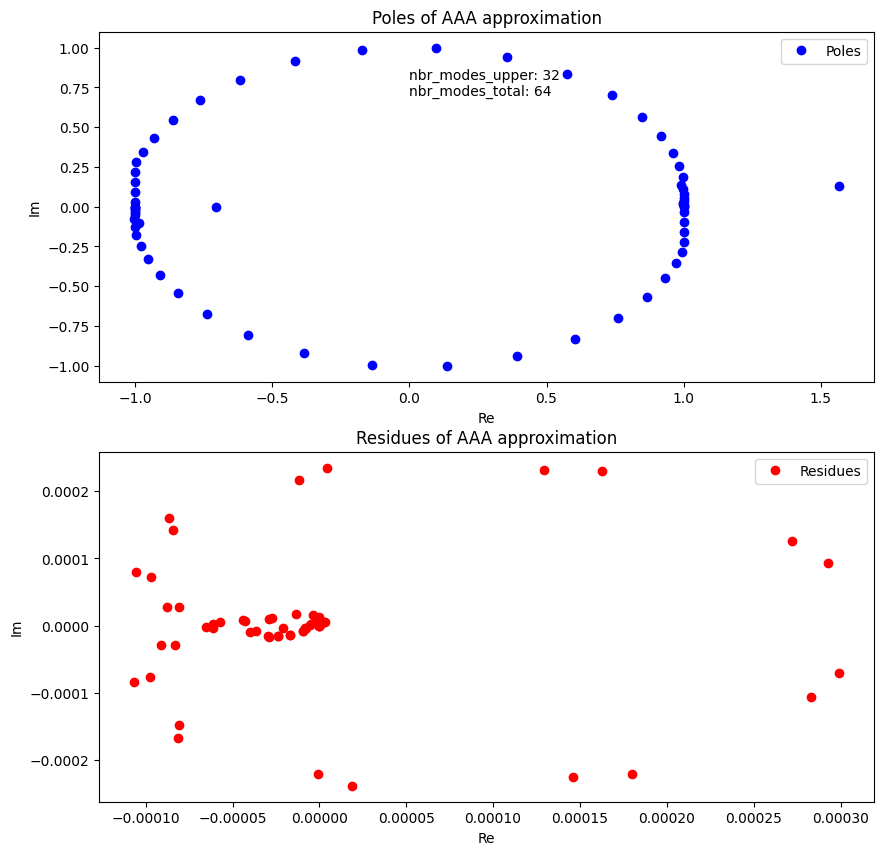

In [30]:
#plot the poles in the complex plane
#subplots in one figure
fig, axs = plt.subplots(2, 1, figsize=(10, 10))
#plot the poles in the complex plane
axs[0].plot(poles.real, poles.imag, 'ro', label = 'Poles', color = 'blue')
axs[0].set_title('Poles of AAA approximation')
axs[0].legend()
axs[0].set_xlabel('Re')
axs[0].set_ylabel('Im')
axs[0].text(0,.7, 'nbr_modes_upper: ' + str(len(poles[poles.imag > 0])) + '\n' + 'nbr_modes_total: ' + str(len(poles)))

#plot the residues in the complex plane
axs[1].plot(residues.real, residues.imag, 'ro', label = 'Residues')
axs[1].set_title('Residues of AAA approximation')
axs[1].legend()
axs[1].set_xlabel('Re')
axs[1].set_ylabel('Im')





Text(0.5, 0, 'Frequency $\\omega$')

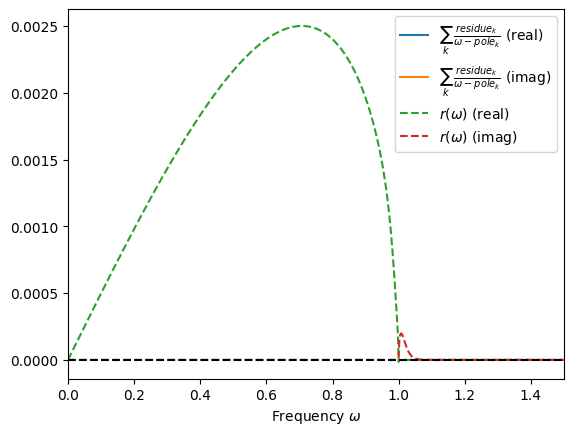

In [31]:
#check that sum over residues divided by poles gives r(z)

#define function as r_check(x) = sum_k residue_k / (x - pole_k)
r_check = lambda x: np.sum([res / (x - pole) for res, pole in zip(residues, poles)])

#range in which we want to plot the function
x_range = np.linspace(0,20,10000)

#evaluate r_check(x) for each x in x_range
vals = np.array([r_check(x) for x in x_range])


#plot the real and imaginary part of r(x) and the real and imaginary part of r_check(x)
plt.figure()
plt.plot(x_range, vals.real, label = r'$\sum_k \,\frac{residue_k }{ \omega - pole_k}$' + ' (real)' )
plt.plot(x_range, vals.imag, label = r'$\sum_k \,\frac{residue_k }{ \omega - pole_k}$' + ' (imag)' )
plt.plot(x_range, np.real(r(x_range)), label = r'$r(\omega)$' + ' (real)' , linestyle = '--')
plt.plot(x_range, np.imag(r(x_range)), label = r'$r(\omega)$' + ' (imag)' , linestyle = '--')
#for i in range(len(poles)):
#    plt.plot(x_range, residues[i] / (x_range - poles[i]), label = 'residue ' + str(i))
plt.hlines(0, 0, 10, color = 'k', linestyle = '--')
plt.legend()
plt.xlim(0, 1.5)
plt.xlabel('Frequency ' + r'$\omega$')

Text(0, 0.5, 'Error')

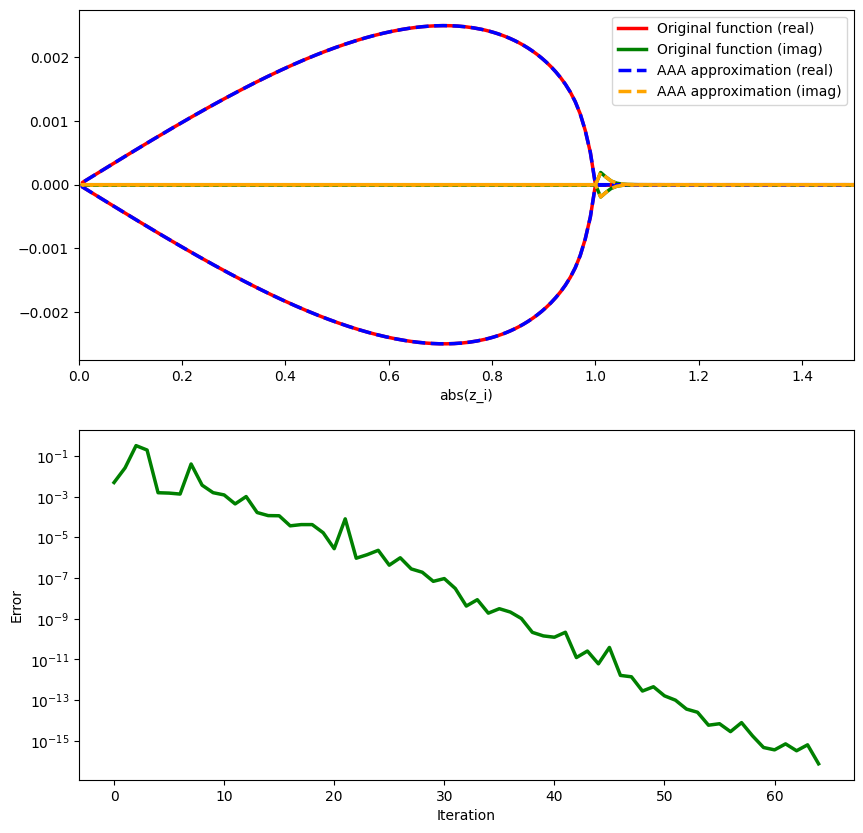

In [32]:

#check that the function is correctly approximated

F_AAA = r(Z) #values computed based on the AAA approximation

#figure with two subplots
fig, axs = plt.subplots(2, 1, figsize=(10, 10))
#first plot original and reconstructed function
axs[0].plot(abs(Z), F.real, label = 'Original function (real)', linewidth = 2.5, color = 'red')
axs[0].plot(abs(Z), F.imag, label = 'Original function (imag)', linewidth = 2.5, color = 'green')
axs[0].plot(abs(Z), F_AAA.real, label = 'AAA approximation (real)', linestyle = '--', linewidth = 2.5, color = 'blue')
axs[0].plot(abs(Z), F_AAA.imag, label = 'AAA approximation (imag)', linestyle = '--', linewidth = 2.5, color = 'orange')
#f_analyt = 1/(1+np.exp(-beta* Z))  * spec_dens(Z) * Jacobian * np.exp(1.j * np.pi/4)
#axs[0].plot(abs(Z), np.real(f_analyt), label = 'Explicit formula', linestyle = 'dotted', linewidth = 2.5, color = 'black')
axs[0].legend()
axs[0].set_xlabel('abs(z_i)')
axs[0].set_xlim(0, 1.5)
#axs[0].text(0, 1.5, 'f(x) = n(x) * Gamma(x) * Jac(x)\n' +"with " + 'Gamma(x) = sqrt(100 - omega**2)', fontsize = 12)
#plot the error as function of iteration
axs[1].plot(errors, label = 'Error', linewidth = 2.5, color = 'green')
axs[1].set_yscale('log')
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel('Error')



/var/folders/cg/_38xw63s1fg5wbmw91yk0qzr0000gn/T/ipykernel_93987/3183947436.py:2: RuntimeWarning: invalid value encountered in sqrt
  spec_dens = lambda omega: np.sqrt(1 - omega**2)* 1/(1 + np.exp(100* (abs(omega) -1)))
/var/folders/cg/_38xw63s1fg5wbmw91yk0qzr0000gn/T/ipykernel_93987/3183947436.py:2: RuntimeWarning: overflow encountered in exp
  spec_dens = lambda omega: np.sqrt(1 - omega**2)* 1/(1 + np.exp(100* (abs(omega) -1)))


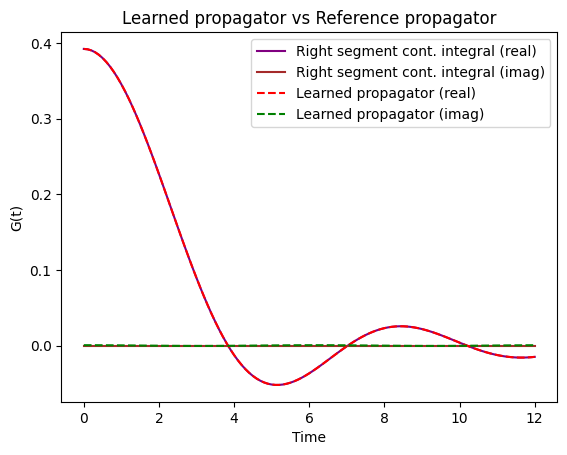

In [33]:
# Vectorized integration for real and imaginary parts
right_segment_cont = np.array([integrate.quad_vec(
    lambda x: 0.5 * r(x) /(x * 0.01) * np.exp(1.j * x * t),
    -np.inf,
    np.inf,
    epsabs=1.49e-6,
    epsrel=1.49e-6
) for t in K.times])

exact_integral  = np.array([integrate.quad_vec(
    lambda x: spec_dens(x) * 1/(1 + np.exp(- params.get_param("beta") * x)) 
 * np.exp(1.j * x * t),
    -np.inf,
    np.inf,
    epsabs=1.49e-6,
    epsrel=1.49e-6
) for t in K.times])



#check that "learned propagator is close to the reference propagator"
residues_upper = residues[poles.imag > 0]
poles_upper = poles[poles.imag > 0]


#sum over all modes
G_learned = 1.j * np.pi * np.sum(residues_upper / (poles_upper * 0.01) * np.exp(1.j * poles_upper * K.times[:,np.newaxis]), axis=1)

#G_ref = K.discrete_integral()

#continuous_integral = D.cont_integral()

#plot the learned propagator and the reference propagator
#plt.plot(K.times, continuous_integral.real, label='Cont. integral (real)', color = 'black', linestyle = 'dotted')
#plt.plot(K.times, continuous_integral.imag, label='Cont. integral (imag)', color = 'black', linestyle = 'dotted')
plt.plot(K.times, right_segment_cont[:,0], label='Right segment cont. integral (real)', color = 'purple', linestyle = '-')
plt.plot(K.times, right_segment_cont[:,1], label='Right segment cont. integral (imag)', color = 'brown', linestyle = '-')
plt.plot(K.times, G_learned.real, label='Learned propagator (real)', color = 'red', linestyle = '--')
plt.plot(K.times, G_learned.imag, label='Learned propagator (imag)', color = 'green', linestyle = '--')
#plt.plot(K.times, exact_integral[:,0], label='Exact propagator (real)', color = 'blue', linestyle = '-')
#plt.plot(K.times, exact_integral[:,1], label='Exact propagator (imag)', color = 'orange', linestyle = '-')
        
#plt.plot(K.times, G_ref.real, label='Reference propagator (real)', color = 'blue', linestyle = '--')
#plt.plot(K.times, G_ref.imag, label='Reference propagator (imag)', color = 'orange', linestyle = '--')
plt.legend()
plt.xlabel('Time')
plt.ylabel('G(t)')
plt.title('Learned propagator vs Reference propagator')
plt.show()
